In [25]:
import os 
import tensorflow as tf
import numpy as np
import pandas as pd 
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt 
from pathlib import Path

In [26]:
datasetPath = Path("../dataset/data_wound_seg_256")

In [27]:
train_image = datasetPath/ "train_images"

In [28]:
train_mask = datasetPath/"train_masks"

In [29]:
test_image= datasetPath/"test_images"

In [30]:
test_mask = datasetPath/"test_masks"

In [31]:
train_image_path = sorted(train_image.glob("*.png"))
train_mask_path = sorted(train_mask.glob("*.png"))
test_image_path = sorted(test_image.glob("*.png"))
test_mask_path = sorted(test_mask.glob("*.png"))

In [32]:
train_image_path = [str(p) for p in train_image_path]
train_mask_path = [str(p) for p in train_mask_path]

test_image_path = [str(p) for p in test_image_path]
test_mask_path = [str(p) for p in test_mask_path]

In [33]:
len(train_image_path)

2208

In [34]:
len(train_mask_path)

2208

In [35]:
len(test_image_path)

552

In [36]:
len(test_mask_path)

552

In [37]:
def loadImageMask(imagePath, maskPath):
    image = tf.io.read_file(imagePath)
    image = tf.image.decode_png(image, channels = 3)
    image = tf.image.convert_image_dtype(image, tf.float32)

    mask = tf.io.read_file(maskPath)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.convert_image_dtype(mask, tf.float32)

    image.set_shape([256, 256, 3])
    mask.set_shape([256, 256, 1])
    return image, mask

In [38]:
BUFFER_SIZE = len(train_image_path)
BATCH_SIZE = 2


In [39]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_image_path, train_mask_path)
)

2026-08-11 10:27:29.260567: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-11 10:27:29.365606: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-11 10:27:29.366728: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [40]:
train_dataset = train_dataset.map(loadImageMask)
train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

In [41]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_image_path, test_mask_path)
)
test_dataset = test_dataset.map(loadImageMask)
test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

In [42]:
for images, masks in test_dataset.take(1):
    print(images.shape)
    print(masks.shape)
    

(2, 256, 256, 3)
(2, 256, 256, 1)


In [43]:
def convert_block(input, filter):
    x = layers.Conv2D(filter, 3, padding="same")(input)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filter, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    return x

In [44]:

def encoder_block(input, filter):
    x = convert_block(input, filter)
    p = layers.MaxPooling2D((2,2))(x)
    return x, p

In [45]:
def decoder_block(input, skip, filter):
    x = layers.Conv2DTranspose(
        filter,
        2,
        strides = 2,
        padding = "same"
    )(input)

    x = layers.Concatenate()([x, skip])
    x = convert_block(x, filter)
    return x

In [46]:
input = layers.Input(shape=(256, 256, 3))

In [47]:
inputs = layers.Input(shape=(256,256,3))

s1, p1 = encoder_block(inputs, 64)
s2, p2 = encoder_block(p1, 128)
s3, p3 = encoder_block(p2, 256)
s4, p4 = encoder_block(p3, 512)

b1 = convert_block(p4, 1024)

d1 = decoder_block(b1, s4, 512)
d2 = decoder_block(d1, s3, 256)
d3 = decoder_block(d2, s2, 128)
d4 = decoder_block(d3, s1, 64)

outputs = layers.Conv2D(
    1,
    1,
    activation="sigmoid"
)(d4)

model = Model(inputs, outputs)

In [48]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256, 64)         1792      ['input_2[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 256, 256, 64)         256       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 re_lu (ReLU)                (None, 256, 256, 64)         0         ['batch_normalization[0][0

In [49]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [50]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "../checkpoints/unet_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [51]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=20,
    callbacks=[checkpoint]
)

Epoch 1/20


2026-08-11 10:27:32.920682: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-08-11 10:27:38.281925: I external/local_xla/xla/service/service.cc:168] XLA service 0x7a1d35b4e430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-11 10:27:38.281954: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-08-11 10:27:38.289379: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786424258.354853    6836 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-08-11 10:27:38.535988: W external/local_tsl/tsl/framework/bfc_allocator.cc:296] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.14GiB with freed_by_count=0. The caller

1104/1104 [==============================] - ETA: 0s - loss: 0.2006 - accuracy: 0.9490
Epoch 1: val_loss improved from inf to 0.06829, saving model to ../checkpoints/unet_best.keras
1104/1104 [==============================] - 205s 168ms/step - loss: 0.2006 - accuracy: 0.9490 - val_loss: 0.0683 - val_accuracy: 0.9889
Epoch 2/20
1104/1104 [==============================] - ETA: 0s - loss: 0.1186 - accuracy: 0.9624
Epoch 2: val_loss improved from 0.06829 to 0.04394, saving model to ../checkpoints/unet_best.keras
1104/1104 [==============================] - 193s 175ms/step - loss: 0.1186 - accuracy: 0.9624 - val_loss: 0.0439 - val_accuracy: 0.9902
Epoch 3/20
1104/1104 [==============================] - ETA: 0s - loss: 0.0928 - accuracy: 0.9674
Epoch 3: val_loss improved from 0.04394 to 0.03116, saving model to ../checkpoints/unet_best.keras
1104/1104 [==============================] - 197s 178ms/step - loss: 0.0928 - accuracy: 0.9674 - val_loss: 0.0312 - val_accuracy: 0.9925
Epoch 4/20
11

In [52]:
import json

with open("../checkpoints/training_history.json", "w") as f:
    json.dump(history.history, f)

print("Training history saved!")

Training history saved!


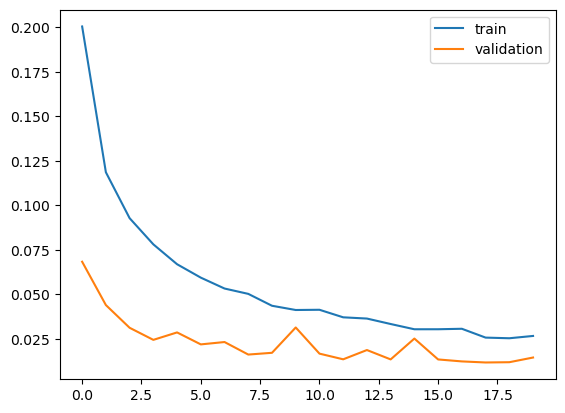

In [53]:
plt.plot(history.history["loss"], label = "train")
plt.plot(history.history["val_loss"], label="validation")
plt.legend()
plt.show()